In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("gpu_log_032826.csv")

def stringToNum(entry):
    if type(entry) != str:
        return entry
    else:
        try:
            return int(entry.strip().split(' ')[0])
        except:
            return float(entry.strip().split(' ')[0])

In [3]:
number_cols_to_convert = [c for c in df.columns if c not in ['timestamp', ' index', ' temperature.gpu']]
df[number_cols_to_convert] = df[number_cols_to_convert].applymap(stringToNum)

/tmp/ipykernel_3178037/3240908883.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[number_cols_to_convert] = df[number_cols_to_convert].applymap(stringToNum)


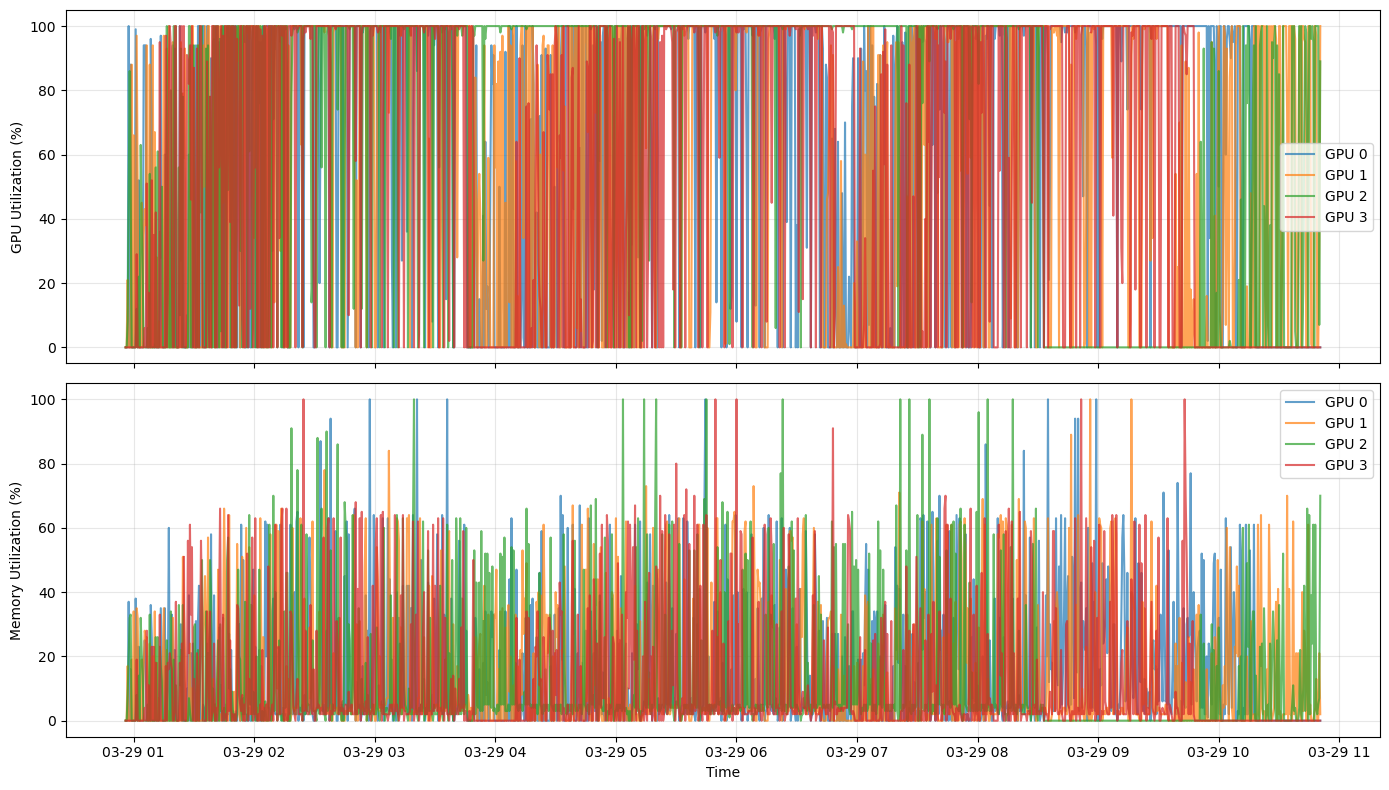

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

fig, axes = plt.subplots(2, 1, figsize = (14,8), sharex = True)

for gpu_id, data in df.groupby(' index'):
    axes[0].plot(data['timestamp'], data[' utilization.gpu [%]'], label = f"GPU {gpu_id}", alpha = 0.7)
    axes[1].plot(data['timestamp'], data[' utilization.memory [%]'], label = f"GPU {gpu_id}", alpha = 0.7)

axes[0].set_ylabel("GPU Utilization (%)")
axes[1].set_ylabel("Memory Utilization (%)")
axes[1].set_xlabel('Time')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

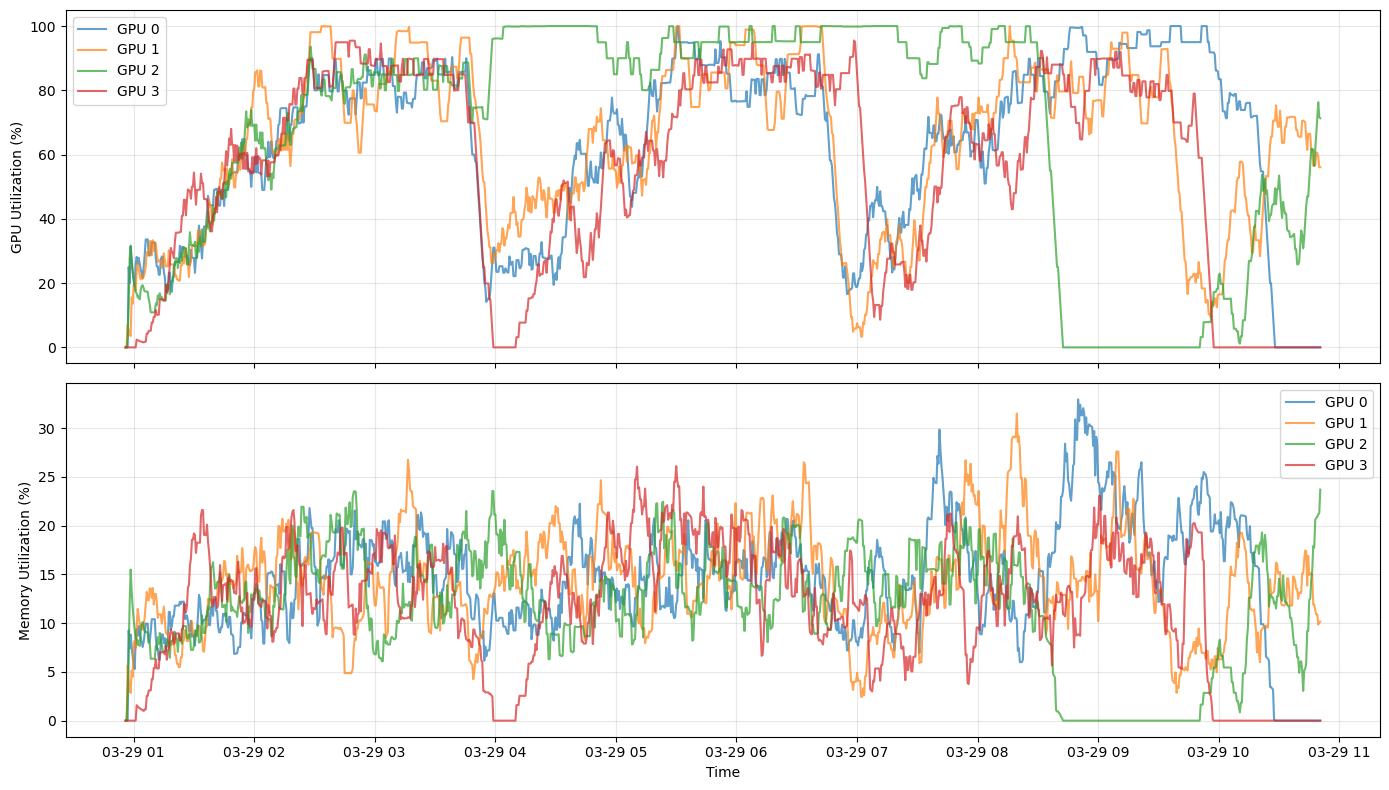

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

fig, axes = plt.subplots(2, 1, figsize = (14,8), sharex = True)

for gpu_id, data in df.groupby(' index'):
    data = data.sort_values('timestamp').set_index('timestamp')
    smoothed = data.rolling('10min').mean()   # 'rolling' needs a timestamp index 

    axes[0].plot(smoothed.index, smoothed[' utilization.gpu [%]'], label = f"GPU {gpu_id}", alpha = 0.7)
    axes[1].plot(smoothed.index, smoothed[' utilization.memory [%]'], label = f"GPU {gpu_id}", alpha = 0.7)

axes[0].set_ylabel("GPU Utilization (%)")
axes[1].set_ylabel("Memory Utilization (%)")
axes[1].set_xlabel('Time')

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()

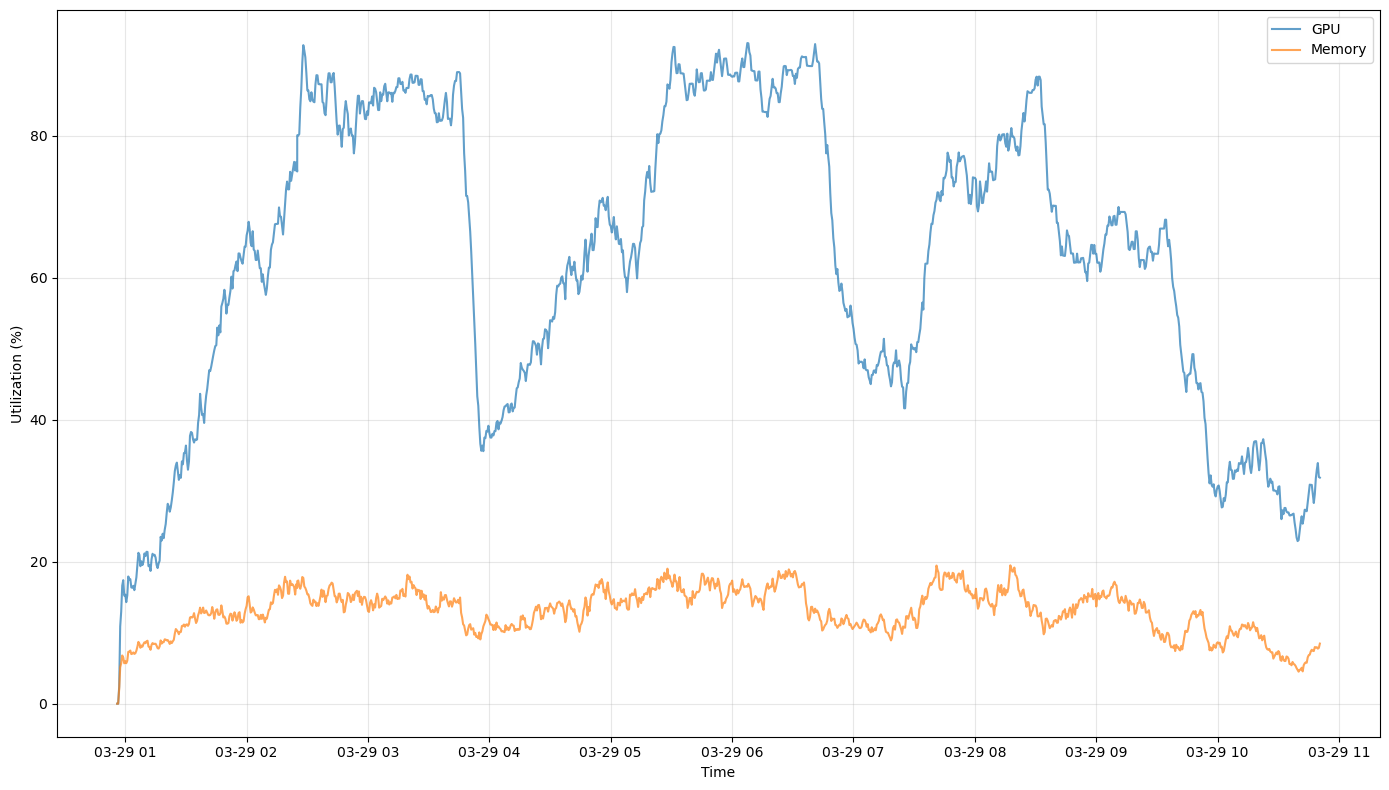

In [6]:
df['timestamp'] = df['timestamp'].dt.round('s')

# Rolling average per GPU at each timestep
rolling_df = (
    df.sort_values('timestamp')
        .set_index('timestamp')
        .groupby(' index')
        .rolling('10min')
        .mean()
        .reset_index()
)

# Avarege across GPUs at each timstep
rolling_df = rolling_df.groupby('timestamp').mean()

fig, ax = plt.subplots(figsize = (14,8))


ax.plot(rolling_df.index, rolling_df[' utilization.gpu [%]'], label = 'GPU', alpha = 0.7)
ax.plot(rolling_df.index, rolling_df[' utilization.memory [%]'], label = 'Memory', alpha = 0.7)

ax.set_ylabel("Utilization (%)")
ax.set_xlabel('Time')


ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()